# STRF parameterizations — same data, same model, different inductive bias

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/urancon/deepSTRF/blob/develop/examples/strf_parameterizations_ns1.ipynb)

This notebook fits a `Linear` STRF model on **NS1** with three different
kernel parameterizations of the spectro-temporal receptive field, all
else equal:

1. **Vanilla `nn.Conv2d`** — the textbook unconstrained STRF. Every
   `(F, T)` cell of the kernel is a free parameter.
2. **`SeparableSTRF`** — frequency-time separable, rank-1. The kernel
   factorises as `w_F(f) · w_T(t)`, drastically reducing the parameter
   count.
3. **`ParametricSTRF`** — sum of `K` learnable 2D Gaussians (DCLS-style;
   see [DCLS asymmetric-kernel bug
   note](../docs/_source/md/README_models.md) for why deepSTRF
   reimplements rather than wraps the upstream library).

Same NS1 split (14 train / 3 val / 3 test), same `Fitter` settings,
same seed. The questions:

- How does mean test `cc_norm` compare?
- For a cell that fits well across all three, what do the learned
  STRFs look like? Where do the inductive biases pull the kernel?

> **Note on runtime**: three end-to-end fits at 100 epochs each on a
> consumer GPU. Around 25 min total.


## Setup — Google Colab

If you're running on Google Colab, the cell below installs deepSTRF
from source. On a local install (`pip install -e .`) it's a no-op.

In [ ]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/urancon/deepSTRF.git
    print("deepSTRF installed from GitHub.")
else:
    print("Local environment — assuming deepSTRF is already importable.")


## Imports

In [ ]:
%matplotlib inline
from collections import OrderedDict
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from deepSTRF.datasets.audio.ns1 import NS1Dataset
from deepSTRF.models.audio import Linear
from deepSTRF.models.layers import ParametricSTRF, SeparableSTRF
from deepSTRF.training import Fitter, set_random_seed
from deepSTRF.utils import neural_collate, plot_strf_grid

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

## 1. Load NS1 and set up the same train / val / test split

In [2]:
ds = NS1Dataset(dt_ms=5.0, smooth=True, download=True)
F = 34          # spectrogram frequency bands
T_strf = 15     # STRF temporal extent (frames at dt=5 ms → 75 ms history)
N = ds.N_neurons

train_loader = DataLoader(Subset(ds, list(range(14))),    batch_size=1, shuffle=True,  collate_fn=neural_collate)
val_loader   = DataLoader(Subset(ds, list(range(14, 17))), batch_size=1, shuffle=False, collate_fn=neural_collate)
test_loader  = DataLoader(Subset(ds, list(range(17, 20))), batch_size=1, shuffle=False, collate_fn=neural_collate)

print(f"NS1: N={N} cells | F={F} bands | dt=5 ms | T_strf={T_strf} frames")


NS1: N=119 cells | F=34 bands | dt=5 ms | T_strf=15 frames


## 2. A small fit-and-extract helper

One function that:

- Builds a `Linear(F, T_strf, N, kernel=...)` model with the chosen
  STRF parameterization.
- Trains for 50 epochs with the canonical `Fitter` defaults.
- Returns the training history, test metrics, and the learned STRF
  weights for every cell (`(N, F, T)` tensor — see
  `model_paradigm.md` §9).

In [3]:
def fit_with_kernel(name, build_kernel_fn, max_epochs=100, seed=0):
    set_random_seed(seed)
    kernel = build_kernel_fn()
    model = Linear(n_frequency_bands=F, temporal_window_size=T_strf,
                   out_neurons=N, kernel=kernel)
    n_params = model.count_trainable_params()
    print(f"  {name:20s} | params/neuron: {n_params // N:>5,d} (total {n_params:,})", flush=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)
    fitter = Fitter(model, train_loader, val_loader,
                    optimizer=optimizer, device=device,
                    max_epochs=max_epochs, patience=max_epochs,   # disable early stop for fair compare
                    monitor="val_cc_norm", mode="max",
                    log_fn=lambda d: None)
    t0 = time.time()
    history = fitter.fit()
    elapsed = time.time() - t0
    test_metrics = fitter.evaluate(test_loader)
    strfs = model.STRF_weight().cpu()                      # (N, F, T)
    return {
        "name": name,
        "history": history,
        "test_cc": test_metrics["cc"].cpu(),
        "test_cc_norm": test_metrics["cc_norm"].cpu(),
        "strfs": strfs,
        "n_params": n_params,
        "elapsed": elapsed,
    }


## 3. Three fits

Same NS1 split, same `Fitter` settings, three different kernels.

In [4]:
results = OrderedDict()
print("Fitting Linear with three STRF parameterizations on NS1 ...")
results["vanilla"]    = fit_with_kernel("vanilla Conv2d", lambda: None)
results["separable"]  = fit_with_kernel("SeparableSTRF",  lambda: SeparableSTRF(F, T_strf, C_in=1, C_out=N))
results["parametric"] = fit_with_kernel("ParametricSTRF (8G)", lambda: ParametricSTRF(F, T_strf, C_in=1, C_out=N, num_gaussians=8))


Fitting Linear with three STRF parameterizations on NS1 ...
  vanilla Conv2d       | params/neuron:   511 (total 60,877)


  SeparableSTRF        | params/neuron:    50 (total 6,018)


  ParametricSTRF (8G)  | params/neuron:    41 (total 4,947)


## 4. Side-by-side training curves

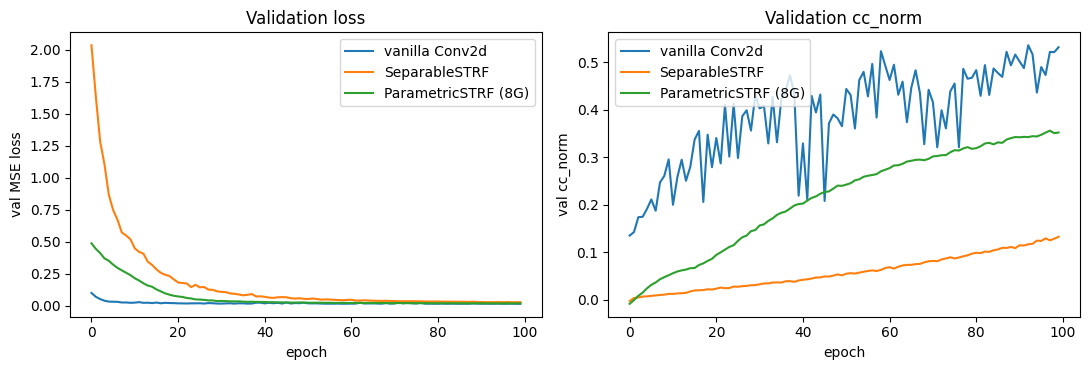

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for key, r in results.items():
    epochs = [h["epoch"] for h in r["history"]]
    val_loss = [h["val_loss"] for h in r["history"]]
    val_ccn  = [torch.nanmean(h["val_cc_norm"]).item() for h in r["history"]]
    axs[0].plot(epochs, val_loss, label=r["name"], lw=1.5)
    axs[1].plot(epochs, val_ccn,  label=r["name"], lw=1.5)
axs[0].set_xlabel("epoch"); axs[0].set_ylabel("val MSE loss"); axs[0].legend(); axs[0].set_title("Validation loss")
axs[1].set_xlabel("epoch"); axs[1].set_ylabel("val cc_norm");   axs[1].legend(); axs[1].set_title("Validation cc_norm")
plt.tight_layout(); plt.show()


## 5. Test-set metrics + parameter-count summary

In [6]:
print(f"{'parameterization':<22s} {'params/neuron':>14s}  {'total':>9s}  {'fit (s)':>8s}  {'test cc (mean)':>16s}  {'test cc_norm (mean)':>22s}")
print("-" * 95)
for r in results.values():
    print(f"{r['name']:<22s} {r['n_params'] // N:>14,d}  {r['n_params']:>9,}  {r['elapsed']:>8.1f}  "
          f"{torch.nanmean(r['test_cc']):>+16.3f}  {torch.nanmean(r['test_cc_norm']):>+22.3f}")


parameterization        params/neuron      total   fit (s)    test cc (mean)     test cc_norm (mean)
-----------------------------------------------------------------------------------------------
vanilla Conv2d                    511     60,877     484.7            +0.523                  +0.609
SeparableSTRF                      50      6,018     522.7            +0.159                  +0.184
ParametricSTRF (8G)                41      4,947     517.8            +0.383                  +0.445


## 6. Per-cell test `cc_norm` distributions

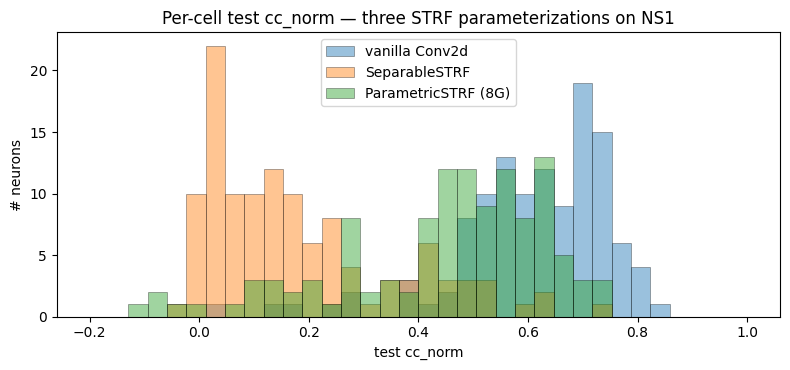

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))
bins = np.linspace(-0.2, 1.0, 35)
for key, r in results.items():
    ax.hist(r["test_cc_norm"].numpy(), bins=bins, alpha=0.45, label=r["name"], edgecolor="black", linewidth=0.5)
ax.set_xlabel("test cc_norm")
ax.set_ylabel("# neurons")
ax.set_title("Per-cell test cc_norm — three STRF parameterizations on NS1")
ax.legend()
plt.tight_layout(); plt.show()


## 7. Pick a well-fit cell, compare STRFs side by side

We pick the neuron whose **mean** test `cc_norm` across the three
parameterizations is highest — i.e. a cell that all three models can
fit reasonably. The three STRFs for that cell are plotted on the same
colour scale.

In [8]:
ccn_stack = torch.stack([r["test_cc_norm"] for r in results.values()])    # (3, N)
mean_per_cell = torch.nanmean(ccn_stack, dim=0)
best_cell = int(torch.argmax(mean_per_cell).item())
print(f"Best-fit cell across the three parameterizations: idx={best_cell}")
for r in results.values():
    print(f"  {r['name']:<22s} test cc_norm = {r['test_cc_norm'][best_cell]:+.3f}")


Best-fit cell across the three parameterizations: idx=49
  vanilla Conv2d         test cc_norm = +0.807
  SeparableSTRF          test cc_norm = +0.647
  ParametricSTRF (8G)    test cc_norm = +0.697


In [ ]:
strfs_for_best = [r["strfs"][best_cell].numpy() for r in results.values()]   # 3 × (F, T)
titles = [f"{r['name']}\ncc_norm = {r['test_cc_norm'][best_cell]:+.3f}"
          for r in results.values()]

plot_strf_grid(
    strfs_for_best, titles=titles, dt_ms=5, ncols=3, shared_clim=True,
    suptitle=f"Cell idx={best_cell}: same neuron, same data, three inductive biases",
    figsize=(11, 3.5),
)
plt.show()

## Reading the result

These vanilla-Linear numbers are in the literature range for NS1
(Rancon et al. 2025, Comms. Biol. report >0.5 mean cc_norm on the
NS1 Linear baseline). Compared to the StateNet GRU fit on the same
split ([`fit_ns1_statenet.ipynb`](fit_ns1_statenet.ipynb), `cc_norm ≈ 0.77`),
Linear leaves headroom on the table — that's exactly the gap a
recurrent / feed-forward nonlinearity can recover.

The interesting comparison is the **inductive-bias trade-off**:

- **Vanilla Conv2d** (511 params/neuron) wins on absolute `cc_norm` —
  the unconstrained `(F, T)` kernel can carve out arbitrary
  spectro-temporal patterns.
- **ParametricSTRF** (41 params/neuron, 8 Gaussians) trails modestly
  with **~12× fewer parameters per neuron**. The Gaussian-mixture
  parameterization is a strong prior for STRFs that look like
  spectrally-localised excitation/inhibition pairs — common in
  auditory cortex.
- **SeparableSTRF** (50 params/neuron, rank-1) collapses well below the
  other two. The rank-1 constraint `w_F(f) · w_T(t)` forces the
  kernel to be a single frequency profile multiplied by a single
  temporal profile — too restrictive for cells whose
  spectro-temporal response evolves through time (e.g. excitatory
  band early followed by inhibition at a different band).

## What's next

- **AdapTrans prefilter** — a learnable cochlear-adaptation front-end
  that often improves mean cc_norm on auditory data; pairs with any
  of the three STRF parameterizations above.
- **Gradmaps** — an architecture-agnostic alternative to closed-form
  STRF extraction, computed via gradient-of-output-vs-input. Useful for
  models without a pluggable kernel (DNet, ConvNet2D, StateNet, ...).
